<h1 style="color:#B2A592;">Python‑based Protein Thermostability Design via MD</h1>

---

This notebook presents a fully Python-based, reproducible molecular dynamics
workflow for protein stability analysis and mutation screening.
As a representative and widely used benchmark system, T4 lysozyme (PDB: 2LZM) is employed as a case study. The methodology itself is general and transferable to other proteins without modification.

---

## Tools and libraries

- **OpenMM** — MD engine used for system preparation and simulation.  
- **MDTraj / MDAnalysis** — trajectory loading and analysis (RMSD, RMSF, native contacts).  
- **Biopython** — PDB retrieval and structure handling.  
- **NumPy / Pandas** — numerical analysis and tabular data processing.  
- **Matplotlib** — plots and figures.  
- **nglview** — interactive 3D visualization in the notebook.  
- **Modeller (conda)** — automated mutant structure generation.  


## Project idea and objectives
The goal of this project is to investigate **protein thermostability** using
**molecular dynamics (MD) simulations** within a fully **Python-based and
reproducible workflow**.

Rather than treating MD as an end in itself, the objective is to use MD as a
**tool for extracting dynamical and structural descriptors** that can be
correlated with protein stability. In particular, the project aims to assess
whether **specific point mutations** lead to improved stability with respect
to the wild-type protein.

The key scientific hypothesis underlying this work is that:

<div style="border-left:4px solid #B2A592; padding-left:12px;">
Protein thermostability is reflected not only in energetic terms, but also in
the <b>ability of the protein to preserve its native structural contacts over
time</b>.
</div>


Mutation selection is performed in a **data-driven yet biologically informed
manner**, combining MD-derived observables with structural and environmental
constraints to identify plausible stabilizing variants.

From a methodological perspective, the project is designed to:
- be entirely **Python-driven**, with a single Jupyter Notebook as final deliverable;
- integrate external tools only when necessary, and exclusively through
  programmatic (non-interactive) calls;
- demonstrate a modern bioinformatics workflow combining **MD simulations,
  structural analysis, and automated mutation screening**.

The final outcome is a comparative analysis of the wild-type protein and selected
variants, based on **dynamical stability metrics extracted from MD trajectories**.


## Literature background: native contacts and protein stability

Protein stability is not fully captured by static structural or energetic
descriptors alone, but is strongly influenced by the **dynamical behavior**
of the protein.

Several molecular dynamics studies have shown that thermostable proteins tend
to preserve a larger fraction of their **native structural contacts** during
thermal motion. In particular, Bekker et al.[1] demonstrated a clear correlation
between protein thermal stability and the persistence of native contacts
observed along MD trajectories.

Motivated by this evidence, we adopt the **fraction of native contacts (Q)**
as a central descriptor of protein stability. In this work:
- native contacts are defined from the equilibrated wild-type protein;
- the same contact set is monitored in mutant simulations;
- variants showing increased average contact preservation are interpreted as
  dynamically more stable.

This metric provides a physically intuitive and MD-native measure of stability,
well suited for automated and reproducible analysis pipelines.


## Data-driven mutant identification workflow

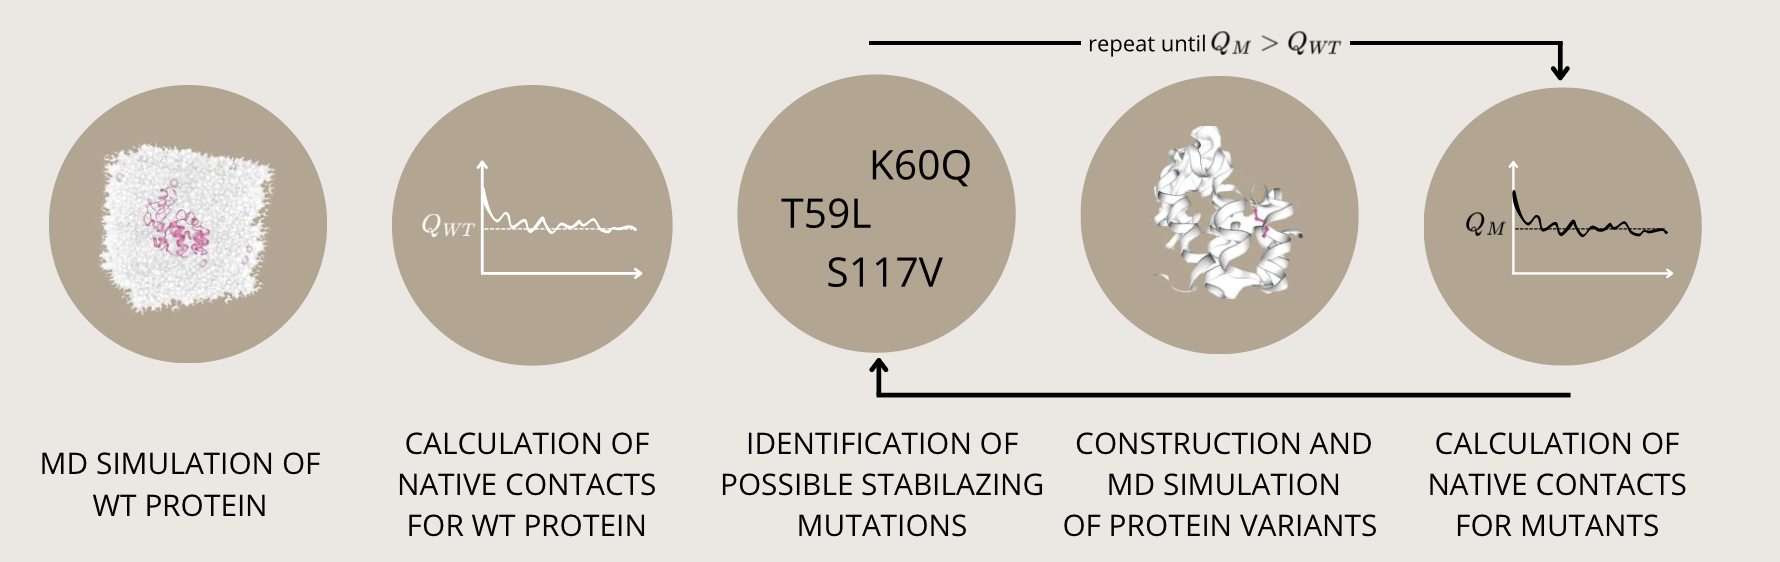

### Index
- <a href="#step" style="color:#B2A592;">Step 1 — WT protein selection and MD simulation</a> 
- <a href="#step" style="color:#B2A592;">Step 2 — Native contact definition and WT baseline calculation</a>
- <a href="#step" style="color:#B2A592;">Step 3 — Mutation proposal</a>
- <a href="#step" style="color:#B2A592;">Step 4 — Variant screening</a>
- <a href="#step" style="color:#B2A592;">Step 5 — Scoring & selection</a>




## Setup

In [ ]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / 'src').exists() and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / 'src').exists():
    raise RuntimeError('Could not locate project root with src/ directory')
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import nglview as nv

from src.openmm_pipeline import download_pdb, prepare_system, run_md
from src.analysis import (
    load_trajectory, compute_rmsd, compute_rmsf, compute_native_contacts_q,
    summarize_metrics, compute_residue_contact_persistence,
)

DATA_DIR = PROJECT_ROOT / 'data'
WT_DIR = DATA_DIR / 'WT'
MUTANT_DIR = DATA_DIR / 'mutants'
WT_DIR.mkdir(parents=True, exist_ok=True)
MUTANT_DIR.mkdir(parents=True, exist_ok=True)


<hr style="border:0; height:3px; background:#B2A592;">

<h2 id="step-1">Step 1 — WT protein selection and MD simulation</h2>

**Objective:** generate a robust reference ensemble for the native protein.

**Operational steps:**
- Selection of the wild-type (WT) protein structure
- Execution of multiple independent WT MD simulations
- Removal of equilibration phase
- Generation of baseline WT trajectories

<hr style="border:0; height:3px; background:#B2A592;">



### Protein selection

The protein chosen for this study is **T4 lysozyme**, a small globular enzyme
originating from bacteriophage T4.

This protein was selected for several reasons:

- It is relatively small (≈160 residues), making it computationally affordable
  for molecular dynamics simulations.
- Its three-dimensional structure has been resolved at high resolution and is
  widely available in public databases.
- It is one of the most extensively studied model systems in the context of
  protein folding, stability, and mutagenesis.
- A large body of experimental literature exists reporting the effects of
  single-point mutations on its thermal stability.

Because of these characteristics, T4 lysozyme is commonly used as a **benchmark
system** for testing both experimental and computational approaches aimed at
understanding protein stability.

The availability of well-characterized stabilizing mutations makes it
particularly suitable for validating computational stability metrics derived
from molecular dynamics simulations.

### 1.1 Structure acquisition (wild-type)
- Download the PDB in legacy format and store it in `data/WT`.


In [207]:
pdb_id = '2LZM'
wt_pdb_path = download_pdb(pdb_id, WT_DIR)

- Visualize WT structure (raw PDB) with interactive viewer 
    
    Secondary structure colors (NGL default)
    - Helix: magenta/pink
    - Beta sheet: yellow
    - Coil/loop: white

In [ ]:
view = nv.show_file(str(wt_pdb_path))
view.clear_representations()
view.add_cartoon(selection='protein', color='sstruc')
view

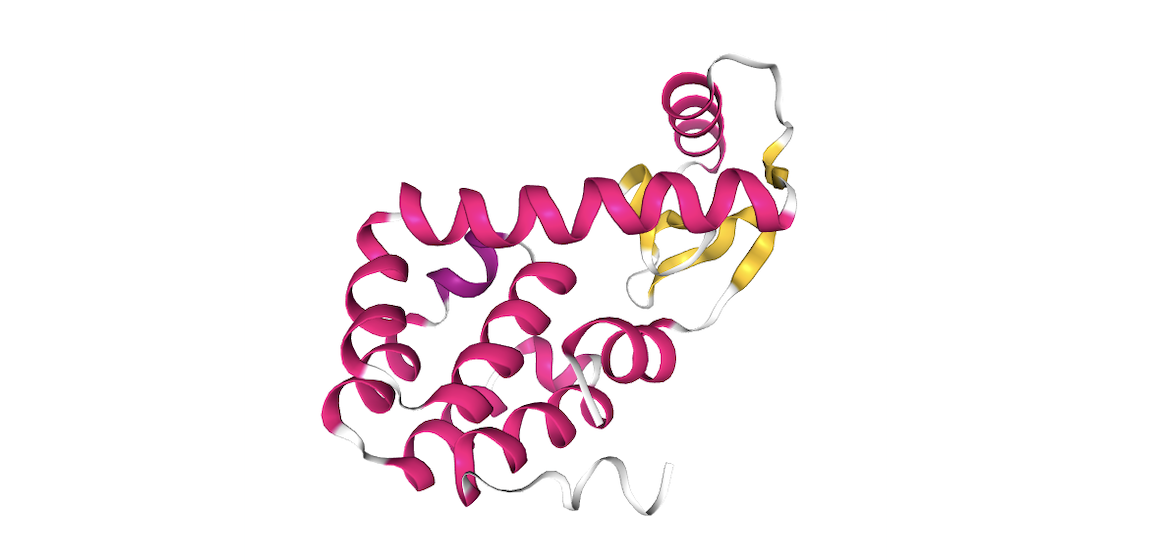

### 1.2 System preparation (OpenMM)
This step builds a simulation-ready system from the raw PDB.
It adds missing hydrogens, assigns force-field parameters,
solvates the protein in a water box, and adds ions for 0.15 M
ionic strength. The prepared structure is saved as `prepared.pdb`
for inspection before running MD.


In [ ]:
prep = prepare_system(
    pdb_path=wt_pdb_path,
    forcefield_files=('charmm36.xml', 'charmm36/water.xml'),
    water_model='tip3p',
    padding_nm=1.0,
    ionic_strength_m=0.15,
    output_pdb_path=WT_DIR / 'prepared.pdb',
    ph=7.0,
)
prep

- Visualize prepared system (with H + solvent)

In [ ]:
prepared_path = WT_DIR / 'prepared.pdb'
view_prep = nv.show_file(str(prepared_path))
view_prep.clear_representations()
view_prep.add_cartoon(selection='protein', color='#ff4fa3')
view_prep.add_spacefill(selection='water', color='white', opacity=0.11)
view_prep.add_spacefill(selection='not protein and not water', color='#f2c1d1', opacity=0.6)
view_prep

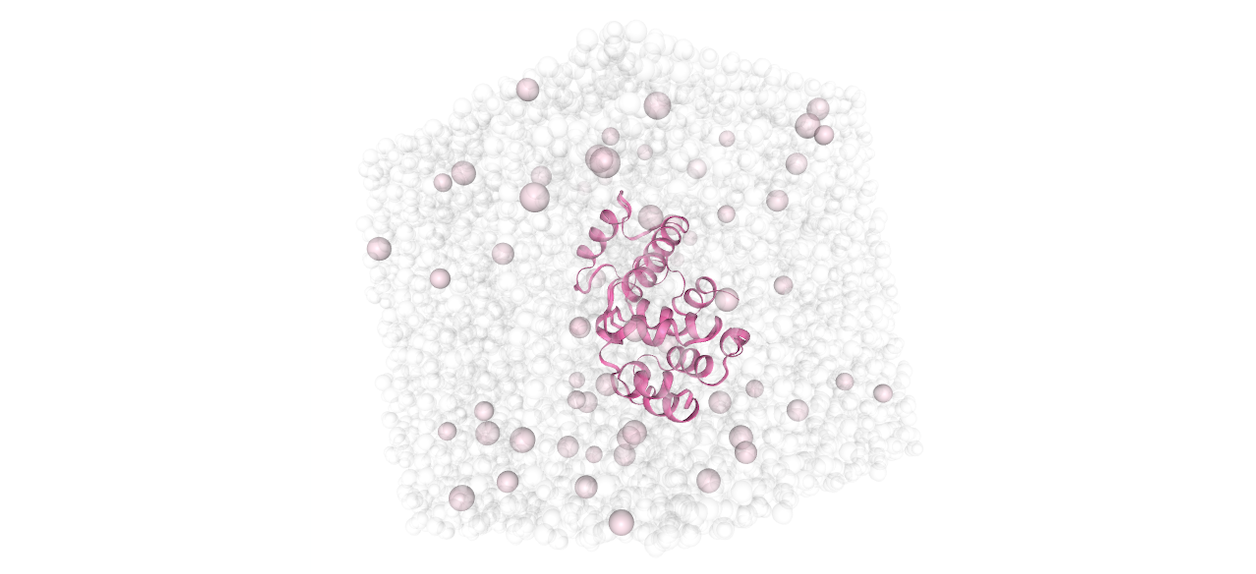

### 1.3 WT Molecular dynamics 

We run multiple WT simulations with different lengths (250 ps, 1.0 ns, 1.2 ns, 1.5 ns, 2.0 ns) and save each trajectory separately. This lets us assess how stable our metrics are across time and reduces the risk that a single short trajectory biases the mutation selection. In later steps, RMSF is computed in blocks across these runs to obtain a robust, low‑noise estimate of flexibility, and the WT native‑contacts baseline Q is always tied to the specific WT run used for comparison.

In [ ]:
# WT MD runs (name -> steps)
wt_runs = {
    "md_250ps": 125_000,
    "md_250ps_2": 125_000,
    "md_1.0ns": 500_000,
    "md_1.2ns": 600_000,
    "md_1.5ns": 750_000,
    "md_2.0ns": 1_000_000,
}

wt_outputs_all = {}

for run_name, n_steps in wt_runs.items():
    wt_run_dir = WT_DIR / run_name
    wt_outputs_all[run_name] = run_md(
        prep=prep,
        output_dir=wt_run_dir,
        temperature_k=300.0,
        friction_ps=1.0,
        timestep_fs=2.0,
        n_steps=n_steps,
        report_interval=500,
    )
    print("Finished:", run_name)

wt_outputs_all

<hr style="border:0; height:3px; background:#B2A592;">

<h2 id="step-2">Step 2 — Native contact definition and WT baseline calculation</h2>

**Objective:** define a stable native reference for structural similarity assessment.

**Operational steps:**
- Definition of native contacts from WT structure
- Computation of native contact persistence across WT trajectories
- Construction of the WT reference distribution
<hr style="border:0; height:3px; background:#B2A592;">


### 2.1 Post-MD analysis: RMSD, RMSF, Native Contacts (Q)

**RMSD (Root Mean Square Deviation)**
- Measures how far the structure deviates from a reference (typically the first frame).
- Low RMSD suggests global structural stability; high RMSD indicates large changes.

**RMSF (Root Mean Square Fluctuation)**
- Measures how much each residue (or atom) fluctuates over time.
- Usually computed per residue (e.g., C-alpha) to identify flexible regions.

**Native contacts (Q)**
- Fraction of native contacts preserved along the trajectory (distances below a cutoff).
- Higher Q means the structure remains closer to the native fold.

In [215]:
import pandas as pd
import contextlib, io

rows = []
wt_runs = {
    "250ps": WT_DIR / "md_250ps",
    "250ps 2": WT_DIR / "md_250ps_2",
    "1ns": WT_DIR / "md_1.0ns",
    "1.2ns": WT_DIR / "md_1.2ns",
    "1.5ns": WT_DIR / "md_1.5ns",
    "2ns": WT_DIR / "md_2.0ns",
}

for name, run_dir in wt_runs.items():
    traj_path = run_dir / "traj.dcd"
    top_path = run_dir / "topology.pdb"
    if not traj_path.exists():
        continue
    with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
        traj = load_trajectory(traj_path, top_path)
    q_values = compute_native_contacts_q(traj, cutoff_nm=0.45)
    rows.append({"run": name, "q_mean": float(q_values.mean())})

pd.DataFrame(rows)


dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)
dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)
dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)
dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)
dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)
dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)


,run,q_mean
0,250ps,0.891641
1,250ps 2,0.889740
2,1ns,0.905466
3,1.2ns,0.894485
4,1.5ns,0.930679
5,2ns,0.912438


#### Plots (RMSD, RMSF, Q)



dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)


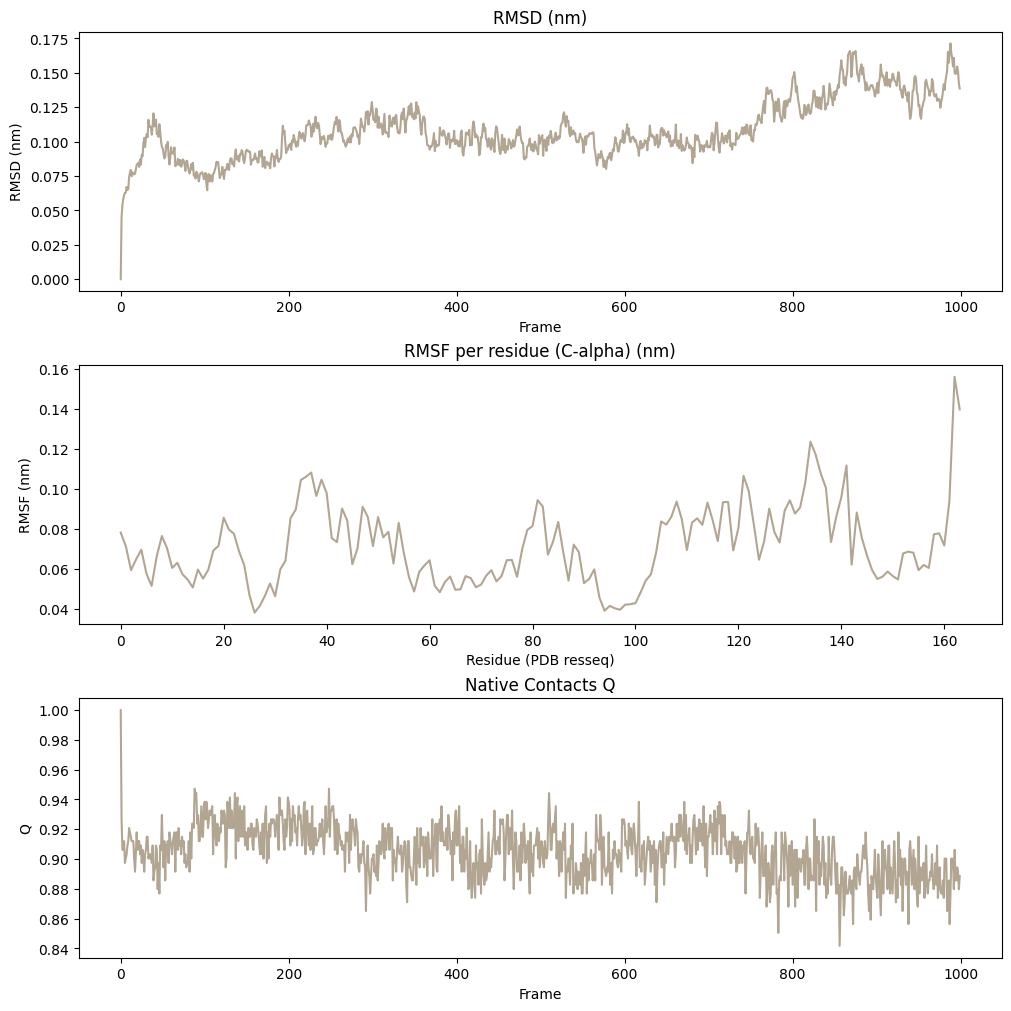

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# List available WT runs (each folder contains traj.dcd + topology.pdb)
# Choose one by setting wt_outputs to the folder you want to analyze. md_1.0ns set by default
# Examples: md_250ps, md_1.0ns, md_1.2ns, md_1.5ns, md.2ns

wt_outputs = {
    "trajectory": WT_DIR / "md_1.0ns" / "traj.dcd",
    "topology": WT_DIR / "md_1.0ns" / "topology.pdb",
}
wt_outputs

traj = load_trajectory(wt_outputs['trajectory'], wt_outputs['topology'])
rmsd = compute_rmsd(traj)
rmsf = compute_rmsf(traj)
q_values = compute_native_contacts_q(traj, cutoff_nm=0.45)
summary = summarize_metrics(rmsd, rmsf, q_values)
summary

fig, axes = plt.subplots(3, 1, figsize=(10, 10), constrained_layout=True)

# RMSD over time
axes[0].plot(rmsd, color="#B2A592")
axes[0].set_title("RMSD (nm)")
axes[0].set_xlabel("Frame")
axes[0].set_ylabel("RMSD (nm)")

# RMSF per residue index (label with PDB residue numbers)
axes[1].plot(rmsf, color="#B2A592")
axes[1].set_title("RMSF per residue (C-alpha) (nm)")
axes[1].set_xlabel("Residue (PDB resseq)")
axes[1].set_ylabel("RMSF (nm)")
ca_indices = traj.topology.select("protein and name CA")
residues = [traj.topology.atom(i).residue for i in ca_indices]
pdb_resseq = [res.resSeq for res in residues]

# Q over time
axes[2].plot(q_values, color="#B2A592")
axes[2].set_title("Native Contacts Q")
axes[2].set_xlabel("Frame")
axes[2].set_ylabel("Q")

plt.show()

<hr style="border:0; height:3px; background:#B2A592;">

## Step 3 — Data-driven identification of stabilizing mutations


**Objective:** identify mutatable residues and plausible stabilizing substitutions.

**Operational steps:**
- Robust RMSF estimation from WT simulations
- SASA-based residue environment classification
- Hard exclusion of structurally or functionally critical residues
- Soft RMSF filtering to retain moderately stable sites
<hr style="border:0; height:3px; background:#B2A592;">



The selection of candidate mutations was designed to balance data-driven
information extracted from molecular dynamics (MD) simulations with
well-established physico-chemical principles of protein stability.
Rather than performing an exhaustive or brute-force mutational scan,
we adopted a filtering strategy aimed at excluding physically implausible
substitutions while allowing stabilizing variants to emerge naturally
from the analysis.


Experimental and computational studies have shown that stabilizing
mutations do not necessarily correspond to the most flexible regions
of a protein. In particular, residues that enhance thermostability often
reside in the hydrophobic core and exhibit relatively low-amplitude
fluctuations, where improvements in packing or contact optimization
can significantly lower the free energy of the folded state.
Consequently, residue-wise RMSF alone is insufficient as a direct
selection criterion.

Instead, RMSF is used here as a *soft descriptor* of local dynamics,
combined with solvent accessibility and structural context to guide
mutation selection.

### 3.1 Robust RMSF strategy (multi-run, block-based)
RMSF is computed per residue using multiple WT runs. We discard burn-in, split into blocks, align within blocks, and compute RMSF per block.
The final RMSF per residue is summarized by median and IQR across all blocks and runs (IQR captures stability across time).


In [ ]:
import numpy as np
import pandas as pd
import mdtraj as md

# Configure runs 
runs = {
    "1.0ns": (WT_DIR / "md_1.0ns"   / "traj.dcd", WT_DIR / "md_1.0ns"   / "topology.pdb"),
    "1.2ns": (WT_DIR / "md_1.2ns" / "traj.dcd", WT_DIR / "md_1.2ns" / "topology.pdb"),
    "1.5ns": (WT_DIR / "md_1.5ns" / "traj.dcd", WT_DIR / "md_1.5ns" / "topology.pdb"),
    "2.0ns": (WT_DIR / "md_2.0ns"   / "traj.dcd", WT_DIR / "md_2.0ns"   / "topology.pdb"),
}

burn_in_frac = 0.20
n_blocks = 4

def block_rmsf(traj, burn_in_frac=0.20, n_blocks=4, atom_sel="protein and name CA"):
    idx = traj.topology.select(atom_sel)
    t = traj.atom_slice(idx)
    n = t.n_frames
    start = int(burn_in_frac * n)
    t = t[start:]
    n = t.n_frames
    block_size = n // n_blocks
    if block_size < 2:
        raise ValueError(f"Too few frames after burn-in: n_frames={n}, block_size={block_size}")
    rmsf_blocks = []
    for b in range(n_blocks):
        block = t[b*block_size : (b+1)*block_size]
        if block.n_frames < 2:
            continue
        # Align within block to remove residual roto-translation
        block.superpose(block, frame=0)
        rmsf = md.rmsf(block, block, frame=0)
        rmsf_blocks.append(rmsf)
    return np.array(rmsf_blocks)

run_blocks = {}
last_traj = None
used_runs = []
for name, (traj_path, top_path) in runs.items():
    if not traj_path.exists() or not top_path.exists():
        print(f"Skipping {name}: missing {traj_path} or {top_path}")
        continue
    traj = md.load(str(traj_path), top=str(top_path))
    ca_count = traj.topology.select("protein and name CA").size
    if 'expected_ca' not in globals():
        expected_ca = ca_count
    elif ca_count != expected_ca:
        raise ValueError(f"CA count mismatch for {name}: {ca_count} vs {expected_ca}")
    last_traj = traj
    run_blocks[name] = block_rmsf(traj, burn_in_frac=burn_in_frac, n_blocks=n_blocks)
    used_runs.append(name)

if not run_blocks:
    raise FileNotFoundError("No trajectories found. Update 'runs' to available MD outputs.")

print("Used runs:", ", ".join(used_runs))

# Residue IDs aligned to CA atoms
ca = last_traj.topology.select("protein and name CA")
ca_atoms = [last_traj.topology.atom(i) for i in ca]
pdb_resseq = [a.residue.resSeq for a in ca_atoms]
resname = [a.residue.name for a in ca_atoms]
res_index = [a.residue.index for a in ca_atoms]

all_blocks = np.concatenate(list(run_blocks.values()), axis=0)
rmsf_median = np.median(all_blocks, axis=0)
rmsf_iqr = np.percentile(all_blocks, 75, axis=0) - np.percentile(all_blocks, 25, axis=0)

rmsf_df = pd.DataFrame({
    "residue_index_0based": res_index,
    "pdb_resseq": pdb_resseq,
    "resname": resname,
    "rmsf_median": rmsf_median,
    "rmsf_iqr": rmsf_iqr,
})

# Exclude termini by sequence index
trim = 5
rmsf_df = rmsf_df.iloc[trim:-trim].reset_index(drop=True)
rmsf_df["rmsf_q"] = rmsf_df["rmsf_median"].rank(pct=True)

# Keep a reference for SASA cell
traj = last_traj

# Show some as example
rmsf_df.head(10)


dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)
dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)
dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)
dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)
Used runs: 1.0ns, 1.2ns, 1.5ns, 2.0ns


,residue_index_0based,pdb_resseq,resname,rmsf_median,rmsf_iqr,rmsf_q
0,5,6,MET,0.044129,0.007373,0.175325
1,6,7,LEU,0.043019,0.005195,0.142857
2,7,8,ARG,0.049782,0.007602,0.396104
3,8,9,ILE,0.053023,0.011104,0.551948
4,9,10,ASP,0.050309,0.013005,0.422078
5,10,11,GLU,0.053901,0.007059,0.571429
6,11,12,GLY,0.055914,0.010079,0.636364
7,12,13,LEU,0.054308,0.006152,0.597403
8,13,14,ARG,0.050669,0.005818,0.467532
9,14,15,LEU,0.047162,0.004637,0.298701


### 3.2 Solvent Exposure (SASA) for Environment Classification 
We estimate per‑residue solvent accessibility (SASA) from a subsampled WT trajectory to keep runtime reasonable.
SASA values are used to classify residues as core, intermediate, or surface, which then guides which mutation types are physically plausible.
This step adds environmental context to the RMSF‑based selection.


In [ ]:
import mdtraj as md
import numpy as np
import pandas as pd

traj_sub = traj[::10]
sasa = md.shrake_rupley(traj_sub, mode="residue")
sasa_mean = sasa.mean(axis=0)

protein_res = [res for res in traj.topology.residues if res.is_protein]
protein_idx = [res.index for res in protein_res]
sasa_mean_protein = sasa_mean[protein_idx]

sasa_df = pd.DataFrame({
    "residue_index_0based": protein_idx,
    "pdb_resseq": [res.resSeq for res in protein_res],
    "resname": [res.name for res in protein_res],
    "sasa": sasa_mean_protein,
})

low_thr = np.quantile(sasa_df["sasa"], 0.33)
high_thr = np.quantile(sasa_df["sasa"], 0.66)
def classify_sasa(x):
    if x <= low_thr:
        return "core"
    if x >= high_thr:
        return "surface"
    return "intermediate"
sasa_df["env"] = sasa_df["sasa"].apply(classify_sasa)

WT_DIR.mkdir(parents=True, exist_ok=True)
sasa_df.to_csv(WT_DIR / "sasa_mean.csv", index=False)
# Show some as example
sasa_df.head(10)


,residue_index_0based,pdb_resseq,resname,sasa,env
0,0,1,MET,0.715384,surface
1,1,2,ASN,0.502442,surface
2,2,3,ILE,0.038849,intermediate
3,3,4,PHE,0.157133,surface
4,4,5,GLU,0.274857,surface
5,5,6,MET,0.000807,core
6,6,7,LEU,0.001183,core
7,7,8,ARG,0.013182,intermediate
8,8,9,ILE,0.006428,intermediate
9,9,10,ASP,0.000394,core


### 3.3 Merge RMSF + SASA and apply hard exclusions
RMSF and SASA tables are merged into a single per‑residue dataset, so each residue has both dynamical and environmental context.
We then remove residues that should not be mutated (e.g., key catalytic positions and highly constrained sites) to avoid biologically implausible candidates.
This creates a clean starting pool for mutation proposal.


In [ ]:
import pandas as pd

all_res = rmsf_df.merge(
    sasa_df,
    on=["residue_index_0based", "pdb_resseq", "resname"],
    how="inner"
).copy()

# Hard exclusions by resname/resSeq 
exclude_resid = {"GLU11", "ASP20"}
all_res["res_id"] = all_res["resname"] + all_res["pdb_resseq"].astype(int).astype(str)
all_res = all_res[~all_res["res_id"].isin(exclude_resid)]

all_res.head(10)


,residue_index_0based,pdb_resseq,resname,rmsf_median,rmsf_iqr,rmsf_q,sasa,env,res_id
0,5,6,MET,0.044129,0.007373,0.175325,0.000807,core,MET6
1,6,7,LEU,0.043019,0.005195,0.142857,0.001183,core,LEU7
2,7,8,ARG,0.049782,0.007602,0.396104,0.013182,intermediate,ARG8
3,8,9,ILE,0.053023,0.011104,0.551948,0.006428,intermediate,ILE9
4,9,10,ASP,0.050309,0.013005,0.422078,0.000394,core,ASP10
6,11,12,GLY,0.055914,0.010079,0.636364,0.001155,core,GLY12
7,12,13,LEU,0.054308,0.006152,0.597403,0.005130,intermediate,LEU13
8,13,14,ARG,0.050669,0.005818,0.467532,0.004163,intermediate,ARG14
9,14,15,LEU,0.047162,0.004637,0.298701,0.003759,intermediate,LEU15
10,15,16,LYS,0.049410,0.007535,0.370130,0.004571,intermediate,LYS16


### 3.4 Environment‑Aware Mutation Rules
We assign allowable substitutions based on the residue’s environment (core, intermediate, surface).
Core sites are restricted to conservative hydrophobic changes; surface sites allow polar/charged swaps; intermediate sites are kept moderately permissive.
These environment‑aware substitution rules are heuristic but grounded in classic principles of protein stability (hydrophobic core packing, solvent exposure, and backbone constraints) [2–4].

This reduces the search space while keeping choices physically reasonable.

In [ ]:
three_to_one = {
    "ALA":"A","CYS":"C","ASP":"D","GLU":"E","PHE":"F",
    "GLY":"G","HIS":"H","ILE":"I","LYS":"K","LEU":"L",
    "MET":"M","ASN":"N","PRO":"P","GLN":"Q","ARG":"R",
    "SER":"S","THR":"T","VAL":"V","TRP":"W","TYR":"Y",
}
core_small = {"A","S","T"}

def allowed_mutations(res1, env):
    if env == "core":
        allowed = ["A","V","I","L","M","F"] # hydrophobic
        if res1 in {"W","Y"}:
            allowed = ["F","Y"]
        if res1 in core_small:
            allowed = ["V","I","L","M"] # bigger-sized hydrophobic
        return [x for x in allowed if x != res1]
    if env == "surface":
        return [x for x in ["D","E","K","R","Q","N","S","T"] if x != res1] # surface mutations: polar/charged
    return [x for x in ["S","T","Q","N","A","V"] if x != res1] # intermediate mutations


### 3.5 Candidate Selection
We first inspect the RMSF range (min/max and quantiles) to choose a reasonable low_q–high_q window that captures “moderately flexible” residues, avoiding both rigid cores and overly floppy termini.
Candidates are then filtered by RMSF quantile, low variability (IQR), and environment‑based exclusions (e.g., Gly/Pro, core charged, hyper‑buried core).

The resulting list is a compact, data‑driven set of residue targets.


In [ ]:
CFG = {
    "env_keep": ["core", "intermediate"],
    "rmsf_low_q": 0.30,   
    "rmsf_high_q": 0.85,  
    "iqr_quantile": 0.50,
}

base = all_res.copy()

low = base["rmsf_median"].quantile(CFG["rmsf_low_q"])
high = base["rmsf_median"].quantile(CFG["rmsf_high_q"])

filtered = base[(base["rmsf_median"] >= low) & (base["rmsf_median"] <= high)].copy()

# IQR threshold dinamica
iqr_thresh = base["rmsf_iqr"].quantile(CFG["iqr_quantile"])
filtered = filtered[filtered["rmsf_iqr"] <= iqr_thresh] #only keep residues with IQR below threshold (stable)

# Environment + trim rules
filtered = filtered[filtered["env"].isin(CFG["env_keep"])].copy()
filtered = filtered[~filtered["resname"].isin(["GLY", "PRO"])]
filtered = filtered[~((filtered["env"] == "core") & (filtered["resname"].isin(["ASP","GLU","ARG","LYS"])))]
filtered = filtered[~((filtered["env"] == "core") & (filtered["sasa"] < 0.001))] 

final_rows = []
for _, row in filtered.iterrows():
    wt = three_to_one.get(row["resname"], "X")
    if wt == "X":
        continue
    muts = allowed_mutations(wt, row["env"])
    if not muts:
        continue
    final_rows.append({
        "chain": row.get("chain", "A"),
        "pdb_resseq": int(row["pdb_resseq"]),
        "resname": row["resname"],
        "wt": wt,
        "env": row["env"],
        "rmsf_median": float(row["rmsf_median"]),
        "rmsf_iqr": float(row["rmsf_iqr"]),
        "rmsf_q": float(row["rmsf_q"]),
        "sasa": float(row["sasa"]),
        "allowed_mutations": muts,
    })

final_table_df = pd.DataFrame(final_rows).sort_values(
    by=["env","rmsf_q"], ascending=[True, False]
).reset_index(drop=True)
final_table_df.head(20)


,chain,pdb_resseq,resname,wt,env,rmsf_median,rmsf_iqr,rmsf_q,sasa,allowed_mutations
0,A,112,ALA,A,core,0.058319,0.004840,0.714286,0.001489,"[V, I, L, M]"
1,A,59,THR,T,core,0.051012,0.002705,0.487013,0.001312,"[V, I, L, M]"
2,A,18,TYR,Y,core,0.050435,0.002659,0.435065,0.001939,[F]
3,A,61,ASP,D,intermediate,0.055049,0.005338,0.610390,0.019464,"[S, T, Q, N, A, V]"
4,A,13,LEU,L,intermediate,0.054308,0.006152,0.597403,0.005130,"[S, T, Q, N, A, V]"
5,A,60,LYS,K,intermediate,0.052822,0.005133,0.538961,0.031604,"[S, T, Q, N, A, V]"
6,A,14,ARG,R,intermediate,0.050669,0.005818,0.467532,0.004163,"[S, T, Q, N, A, V]"
7,A,65,LYS,K,intermediate,0.050182,0.005559,0.415584,0.008243,"[S, T, Q, N, A, V]"
8,A,72,ASP,D,intermediate,0.049651,0.006505,0.389610,0.003107,"[S, T, Q, N, A, V]"
9,A,69,GLN,Q,intermediate,0.049362,0.005477,0.363636,0.003378,"[S, T, N, A, V]"


<hr style="border:0; height:3px; background:#B2A592;">

## Step 4 — Construction and short MD screening of variants

**Objective:** generate mutant structures and perform a rapid stability screen.

**Operational steps:**
- Deterministic down-selection of candidate mutations
- Automatic construction of mutant PDBs from the WT (Modeller)
- Short 250‑ps MD simulations for each variant
- Two replicated screening rounds to reduce stochastic noise

<hr style="border:0; height:3px; background:#B2A592;">


### 4.1 Final Mutation Set
From the filtered residue list, we select a small number of substitutions per site (typically 2) using conservative, chemistry‑aware priorities.
This yields a compact and reproducible mutation set for screening, balancing exploration with computational cost.
These mutations are then passed to the automated build and MD pipeline.

In [70]:
# Pick top-k mutations per residue based on allowed_mutations
def pick_mutations(wt, env, muts, k=2):
    muts = list(muts)

    if env == "core":
        priority = ["V", "L", "I", "M", "A", "F"]
        ranked = [m for m in priority if m in muts]
        return ranked[:k]

    if wt in {"K","R","E","D"}:
        priority = ["Q", "N", "S", "T", "A", "V"]
        ranked = [m for m in priority if m in muts]
        return ranked[:k]

    if wt in {"S","T","N","Q"}:
        priority = ["V", "A", "T", "S", "Q", "N"]
        ranked = [m for m in priority if m in muts]
        return ranked[:k]

    priority = ["V", "A", "L", "I", "M", "S", "T"]
    ranked = [m for m in priority if m in muts]
    return ranked[:k]

final_table_df["picked_mutations"] = final_table_df.apply(
    lambda r: pick_mutations(r["wt"], r["env"], r["allowed_mutations"], k=2),
    axis=1
)

final_table_df[["pdb_resseq","resname","wt","env","allowed_mutations","picked_mutations"]]


,pdb_resseq,resname,wt,env,allowed_mutations,picked_mutations
0,112,ALA,A,core,"[V, I, L, M]","[V, L]"
1,59,THR,T,core,"[V, I, L, M]","[V, L]"
2,18,TYR,Y,core,[F],[F]
3,61,ASP,D,intermediate,"[S, T, Q, N, A, V]","[Q, N]"
4,13,LEU,L,intermediate,"[S, T, Q, N, A, V]","[V, A]"
5,60,LYS,K,intermediate,"[S, T, Q, N, A, V]","[Q, N]"
6,14,ARG,R,intermediate,"[S, T, Q, N, A, V]","[Q, N]"
7,65,LYS,K,intermediate,"[S, T, Q, N, A, V]","[Q, N]"
8,72,ASP,D,intermediate,"[S, T, Q, N, A, V]","[Q, N]"
9,69,GLN,Q,intermediate,"[S, T, N, A, V]","[V, A]"


In [72]:
import pandas as pd

mut_list = []
for _, row in final_table_df.iterrows():
    for m in row["picked_mutations"]:
        mut_list.append({
            "chain": row["chain"],
            "pdb_resseq": int(row["pdb_resseq"]),
            "wt": row["wt"],
            "mut": m,
            "env": row["env"],
            "mutation": f"{row['wt']}{int(row['pdb_resseq'])}{m}",  # WT-style
        })

mut_df_small = pd.DataFrame(mut_list)
mut_df_small


,chain,pdb_resseq,wt,mut,env,mutation
0,A,112,A,V,core,A112V
1,A,112,A,L,core,A112L
2,A,59,T,V,core,T59V
3,A,59,T,L,core,T59L
4,A,18,Y,F,core,Y18F
5,A,61,D,Q,intermediate,D61Q
6,A,61,D,N,intermediate,D61N
7,A,13,L,V,intermediate,L13V
8,A,13,L,A,intermediate,L13A
9,A,60,K,Q,intermediate,K60Q


### 4.2 Mutant Structure Generation (Modeller)

Each selected mutation is applied to the WT structure using Modeller, producing a new PDB for every variant.

This step is fully automated and produces one folder per mutant, ready for system preparation and MD.
All generated structures are saved for reproducibility.

Run this in the `modeller_env` conda environment to create mutant structures.

In [ ]:
import subprocess

mutation_list = ",".join(mut_df_small["mutation"].tolist())
cmd = [
    "conda", "run", "-n", "modeller_env",
    "python", "../scripts/modeller_mutate.py",
    "--pdb", "../data/WT/2LZM.pdb",
    "--mutations", mutation_list,
    "--outdir", "../data/mutations",
    "--mutation-format", "wt",
    "--default-chain", "A",
]

result = subprocess.run(cmd, capture_output=True, text=True)
print("STDOUT:\n", result.stdout)
print("STDERR:\n", result.stderr)


STDOUT:
 
                         MODELLER 10.8, 2025/11/04, r13157

     PROTEIN STRUCTURE MODELLING BY SATISFACTION OF SPATIAL RESTRAINTS


                     Copyright(c) 1989-2025 Andrej Sali
                            All Rights Reserved

                             Written by A. Sali
                               with help from
              B. Webb, M.S. Madhusudhan, M-Y. Shen, G.Q. Dong,
          M.A. Marti-Renom, N. Eswar, F. Alber, M. Topf, B. Oliva,
             A. Fiser, R. Sanchez, B. Yerkovich, A. Badretdinov,
                     F. Melo, J.P. Overington, E. Feyfant
                 University of California, San Francisco, USA
                    Rockefeller University, New York, USA
                      Harvard University, Cambridge, USA
                   Imperial Cancer Research Fund, London, UK
              Birkbeck College, University of London, London, UK


Kind, OS, HostName, Kernel, Processor: 4, Darwin Auroras-MacBook-Pro-2.local 25.1.0 arm64
Date and t

### 4.3 Mutant MD screening 
Each mutant is prepared and simulated with a short 250‑ps MD run to obtain a fast estimate of stability.
We compute the native‑contacts fraction Q for each mutant and compare it to the WT baseline.
Results are saved to CSV for reproducibility and later ranking.


In [ ]:
import csv
import pandas as pd

wt_q_mean = float(q_values.mean())
mutant_results = []

start_idx = 0
stop_idx = 30
mutations = mut_df_small["mutation"].tolist()[start_idx:stop_idx]

MUTANT_DIR = DATA_DIR / "mutations"

csv_path = MUTANT_DIR / "screening_q_2.csv"
write_header = not csv_path.exists()

with open(csv_path, "a", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=["mutation", "q_mean", "q_delta"])
    if write_header:
        writer.writeheader()

    for mut in mutations:
        mut_dir = MUTANT_DIR / mut
        mut_pdb = mut_dir / "structure.pdb"
        if not mut_pdb.exists():
            print(f"Skipping {mut}: missing {mut_pdb}")
            continue

        mut_prep = prepare_system(
            pdb_path=mut_pdb,
            forcefield_files=("charmm36.xml", "charmm36/water.xml"),
            water_model="tip3p",
            padding_nm=1.0,
            ionic_strength_m=0.15,
            output_pdb_path=mut_dir / "prepared.pdb",
            ph=7.0,
        )
        mut_outputs = run_md(
            prep=mut_prep,
            output_dir=mut_dir / "md_250ps",
            temperature_k=300.0,
            friction_ps=1.0,
            timestep_fs=2.0,
            n_steps=125000,
            report_interval=500,
        )
        mut_traj = load_trajectory(mut_outputs["trajectory"], mut_outputs["topology"])
        mut_q = compute_native_contacts_q(mut_traj, cutoff_nm=0.45)
        mut_q_mean = float(mut_q.mean())

        row = {"mutation": mut, "q_mean": mut_q_mean, "q_delta": mut_q_mean - wt_q_mean}
        writer.writerow(row)
        f.flush()
        mutant_results.append(row)
        print(mut, mut_q_mean)

mutant_results


### 4.4 Paired WT Baseline and Robust ΔQ Scoring

To reduce stochastic noise, we run **two independent 250‑ps WT simulations** and record their Q means.  
Each mutant is also screened twice (round 1 and round 2). We compute **paired ΔQ** values using the WT baseline from the same round, then aggregate:

- ΔQ_avg = mean(ΔQ₁, ΔQ₂)  
- ΔQ_std = standard deviation across rounds  
- consistent_sign checks whether both rounds agree in sign

This provides a simple but robust statistical filter for selecting stable improvements rather than single‑run artifacts.


In [ ]:
import pandas as pd

rows = []
traj = load_trajectory(WT_DIR / "md_250ps" / "traj.dcd",WT_DIR / "md_250ps" / "topology.pdb")
rows.append({"run": "WT 250 ps", "q_mean": float(compute_native_contacts_q(traj, cutoff_nm=0.45).mean())})
traj = load_trajectory(WT_DIR / "md_250ps_2" / "traj.dcd",WT_DIR / "md_250ps_2" / "topology.pdb")
rows.append({"run": "WT 250 ps (rep2)", "q_mean": float(compute_native_contacts_q(traj, cutoff_nm=0.45).mean())})
pd.DataFrame(rows).style.hide(axis="index")


dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)
dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)


run,q_mean
WT 250 ps,0.891641
WT 250 ps (rep2),0.889740


In [ ]:
import pandas as pd
import numpy as np

df1 = pd.read_csv("../data/mutations/screening_q.csv")[["mutation","q_mean"]].rename(columns={"q_mean":"q_mean_1"})
df2 = pd.read_csv("../data/mutations/screening_q_2.csv")[["mutation","q_mean"]].rename(columns={"q_mean":"q_mean_2"})
df = df1.merge(df2, on="mutation", how="inner")

WT_q_md  = 0.8916413373860183  # WT 250 ps round 1 
WT_q_md2 = 0.8897396449704142  # WT 250 ps round 2

df["q_delta_1"] = df["q_mean_1"] - WT_q_md
df["q_delta_2"] = df["q_mean_2"] - WT_q_md2

df["q_delta_avg"] = df[["q_delta_1", "q_delta_2"]].mean(axis=1)
df["q_delta_std"] = df[["q_delta_1", "q_delta_2"]].std(axis=1, ddof=1)
df["consistent_sign"] = np.sign(df["q_delta_1"]) == np.sign(df["q_delta_2"])

df = df.sort_values("q_delta_avg", ascending=False).reset_index(drop=True)
df.to_csv("../data/mutations/final_screening_paired.csv", index=False)

df

,mutation,q_mean_1,q_mean_2,q_delta_1,q_delta_2,q_delta_avg,q_delta_std,consistent_sign
0,T59V,0.914594,0.932463,0.022953,0.042724,0.032838,0.013980,True
1,T59L,0.927988,0.911807,0.036346,0.022068,0.029207,0.010097,True
2,K60Q,0.916561,0.914942,0.024920,0.025202,0.025061,0.000200,True
3,S117V,0.908412,0.918747,0.016771,0.029007,0.022889,0.008653,True
4,D61N,0.913342,0.913523,0.021700,0.023783,0.022742,0.001473,True
5,R14N,0.918857,0.907589,0.027216,0.017849,0.022533,0.006623,True
6,K65Q,0.917447,0.903643,0.025805,0.013903,0.019854,0.008416,True
7,D72N,0.908211,0.910313,0.016569,0.020574,0.018571,0.002832,True
8,Q69V,0.907101,0.910102,0.015459,0.020362,0.017911,0.003467,True
9,Y18F,0.891714,0.924394,0.000073,0.034654,0.017364,0.024453,True


<hr style="border:0; height:3px; background:#B2A592;">

## Step 5 — Top‑scoring candidates and final selection

**Objective:** validate the strongest short‑run hits with longer MD and confirm stability gains.

**Operational steps:**
- Select top candidates from the paired 250‑ps screen
- Run long MD (2 ns) for each selected mutant
- Compute Q and compare against WT long‑run baseline
- Rank final variants using long‑run ΔQ

<hr style="border:0; height:3px; background:#B2A592;">


### 5.1 Top mutants selection (paired 250‑ps screen)
We retain mutants that are consistent across replicas (same ΔQ sign) and show low variability (q_delta_std).
From these, we select the top‑N by q_delta_avg.


In [ ]:
import pandas as pd

max_std = 0.015 
top_n = 5

stable = df[(df["consistent_sign"]) & (df["q_delta_std"] <= max_std)].copy()
stable = stable.sort_values("q_delta_avg", ascending=False)

selected = stable.head(top_n).reset_index(drop=True)
selected


,mutation,q_mean_1,q_mean_2,q_delta_1,q_delta_2,q_delta_avg,q_delta_std,consistent_sign
0,T59V,0.914594,0.932463,0.022953,0.042724,0.032838,0.013980,True
1,T59L,0.927988,0.911807,0.036346,0.022068,0.029207,0.010097,True
2,K60Q,0.916561,0.914942,0.024920,0.025202,0.025061,0.000200,True
3,S117V,0.908412,0.918747,0.016771,0.029007,0.022889,0.008653,True
4,D61N,0.913342,0.913523,0.021700,0.023783,0.022742,0.001473,True



The selected mutations improve native-like behavior through three complementary mechanisms:  
- local rigidification (T59V, T59L),  
- charge neutralization in semi-buried regions (K60Q, D61N), and  
- subtle packing optimization at a known stabilizing site (S117V).


### 5.2 Long MD validation (2 ns)
We re‑simulate the top candidates from the paired screen with a longer 2‑ns run.
For each mutant we compute Q and save a per‑mutant summary, then compare against the WT 2‑ns baseline.


In [ ]:
from pathlib import Path
import csv

mutations = selected["mutation"].tolist()


for mut in mutations:
    mut_dir = DATA_DIR / "mutations" / mut
    mut_pdb = mut_dir / "structure.pdb"

    if not mut_pdb.exists():
        print(f"Missing {mut_pdb}, skipping.")
        continue

    mut_prep = prepare_system(
        pdb_path=mut_pdb,
        forcefield_files=("charmm36.xml", "charmm36/water.xml"),
        water_model="tip3p",
        padding_nm=1.0,
        ionic_strength_m=0.15,
        output_pdb_path=mut_dir / "prepared.pdb",
        ph=7.0,
    )

    mut_outputs = run_md(
        prep=mut_prep,
        output_dir=mut_dir / "md_2ns",
        temperature_k=300.0,
        friction_ps=1.0,
        timestep_fs=2.0,
        n_steps=1_000_000,
        report_interval=5000,
    )

    mut_traj = load_trajectory(mut_outputs["trajectory"], mut_outputs["topology"])
    mut_q = compute_native_contacts_q(mut_traj, cutoff_nm=0.45)
    mut_q_mean = float(mut_q.mean())

    print(mut, "Q_mean:", mut_q_mean)

    summary_path = mut_dir / "md_2ns_q_summary.csv"
    with open(summary_path, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=["mutation", "q_mean"])
        writer.writeheader()
        writer.writerow({"mutation": mut, "q_mean": mut_q_mean})

    print("Saved:", summary_path)


### 5.3 Final ranking and top‑2 selection
We rank the long‑run mutants by ΔQ relative to the WT 2‑ns baseline.
The top two variants (highest ΔQ) are retained as the final candidates for reporting.

In [ ]:
import pandas as pd

traj = load_trajectory(WT_DIR / "md_2.0ns" / "traj.dcd",
                       WT_DIR / "md_2.0ns" / "topology.pdb")
q_values = compute_native_contacts_q(traj, cutoff_nm=0.45)
WT_q_2ns = float(q_values.mean())

pd.DataFrame([{"run": "WT 2.0 ns", "q_mean": WT_q_2ns}]).style.hide(axis="index")



dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)


run,q_mean
WT 2.0 ns,0.912438


In [214]:
import pandas as pd
from pathlib import Path

mutations = selected["mutation"].tolist()

rows = []
for mut in mutations:
    summary_path = DATA_DIR / "mutations" / mut / "md_2ns_q_summary.csv"
    if not summary_path.exists():
        print(f"Missing: {summary_path}")
        continue
    df = pd.read_csv(summary_path)
    q_mean = float(df["q_mean"].iloc[0])
    rows.append({
        "mutation": mut,
        "q_mean": q_mean,
    })

top2 = (
    pd.DataFrame(rows)
    .sort_values("q_mean", ascending=False)
    .head(2)
    .reset_index(drop=True)
)

top2.style.hide(axis="index")


mutation,q_mean
S117V,0.921933
K60Q,0.912864


<hr style="border:0; height:3px; background:#B2A592;">

## Final conclusion (literature validation)

Our top-ranked mutant is **S117V**, which is reported in the literature [5] as the most stabilizing single‑point mutation in T4 lysozyme (ΔTm ≈ +5.1 °C).  
S117 is an intermediate‑burial site; replacing Ser with Val improves hydrophobic packing without disrupting the fold.  
The stabilizing effect is subtle in a single short simulation, but becomes consistent across replicated screens, which validates both the **data‑driven selection** and the **paired‑screening strategy** used in this pipeline.
<hr style="border:0; height:3px; background:#B2A592;">

## References

[1] Bekker, G.-J., Ma, B., & Kamiya, N. (2019).  
*Thermal stability of single-domain antibodies estimated by molecular dynamics simulations.*

[2] Dill, K. A. (1990). Dominant forces in protein folding. *Biochemistry*, 29(31), 7133–7155.

[3] Rose, G. D., et al. (1985). Hydrophobicity of amino acid residues in globular proteins. *Science*, 229(4716), 834–838.

[4] Eisenberg, D., & McLachlan, A. D. (1986). Solvation energy in protein folding and binding. *Nature*, 319, 199–203.

[5] Baase, W. A., Liu, L., Tronrud, D. E., & Matthews, B. W. (2010).  
*Lessons from the lysozyme of phage T4.* *Protein Science*, 19(4), 631–641. https://doi.org/10.1002/pro.344
